In [2]:
!pip install dask

In [3]:
import dask.dataframe as dd

df = dd.read_parquet('/Users/pitzsb1/Documents/train_eegs')
df.head()

,Fp1,F3,C3,P3,F7,T3,T5,O1,Fz,Cz,Pz,Fp2,F4,C4,P4,F8,T4,T6,O2,EKG
0,-75.360001,86.379997,65.470001,62.580002,170.350006,92.370003,39.68,89.870003,18.260000,-28.440001,-15.190000,16.93,13.81,-42.160000,78.099998,-143.649994,121.239998,-1.470000,72.550003,-3090.090088
1,-107.739998,53.139999,32.590000,21.950001,140.500000,59.070000,4.26,53.310001,-18.490000,-63.270000,-52.110001,-13.23,-16.42,-80.430000,64.449997,-168.500000,88.400002,-28.520000,40.250000,5560.439941
2,-103.050003,46.330002,10.750000,9.150000,137.820007,50.950001,-3.50,45.070000,-20.879999,-66.629997,-69.750000,-9.20,-21.40,-93.089996,5.120000,-176.089996,51.689999,-38.639999,31.820000,-4161.450195
3,-75.099998,77.870003,40.150002,31.790001,166.630005,76.769997,17.99,67.650002,11.140000,-32.950001,-38.509998,14.77,9.79,-66.480003,48.220001,-147.990005,86.629997,-18.639999,62.509998,31769.970703
4,-97.919998,58.209999,27.330000,5.340000,144.080002,47.200001,-10.43,40.250000,-12.350000,-52.500000,-54.919998,-10.07,-8.04,-90.820000,67.269997,-164.710007,80.680000,-36.520000,41.830002,6879.720215


In [4]:
df_sample = df.sample(frac=0.001).compute()

In [5]:
df = dd.read_parquet(
    '/Users/pitzsb1/Documents/train_eegs',
    columns=['Fp1', 'Fp2']  # 일부 채널만
)

In [6]:
df.head()

,Fp1,Fp2
0,-75.360001,16.93
1,-107.739998,-13.23
2,-103.050003,-9.20
3,-75.099998,14.77
4,-97.919998,-10.07


In [15]:
print(window.head())
print(window.shape)

Fp1   -12.230000
Fp2    86.129997
Name: 5847, dtype: float32
(2,)


In [17]:
print(window.describe())

count     2.000000
mean     36.949997
std      69.551025
min     -12.230000
25%      12.360001
50%      36.949997
75%      61.539997
max      86.129997
Name: 5847, dtype: float64


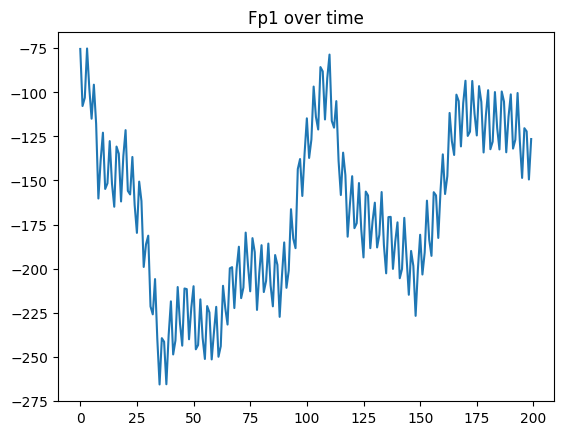

In [21]:
import matplotlib.pyplot as plt

plt.plot(df['Fp1'].head(200)) # 5ms, 1초 동안 200번 측정됨 (200Hz)
plt.title('Fp1 over time')
plt.show()

-> 느리고 큰 흐름: 저주파 성분(델타)

-> 잔떨림: 고주파 성분(베타)

-> 노이즈 여부: 완전 랜덤도 아니고 부드럽지도 않음. 정상 EEG


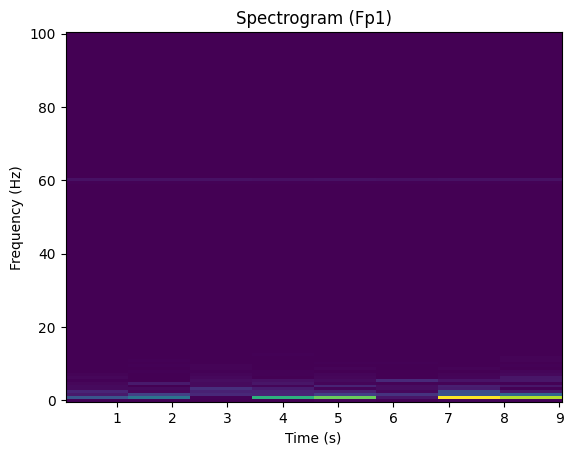

In [33]:
from scipy.signal import spectrogram
import matplotlib.pyplot as plt

sig = df['Fp1'].head(2000)  # 10초 정도

f, t, Sxx = spectrogram(sig, fs=200)

plt.pcolormesh(t, f, Sxx)
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.title('Spectrogram (Fp1)')
plt.show()

-> 아래쪽(저주파)만 살짝 밝고, 위쪽은 대부분 보라색 = 에너지가 대부분 저주파에 몰려 있음 (정상적 EEG 특성)

Text(0.5, 1.0, 'Channel Correlation')

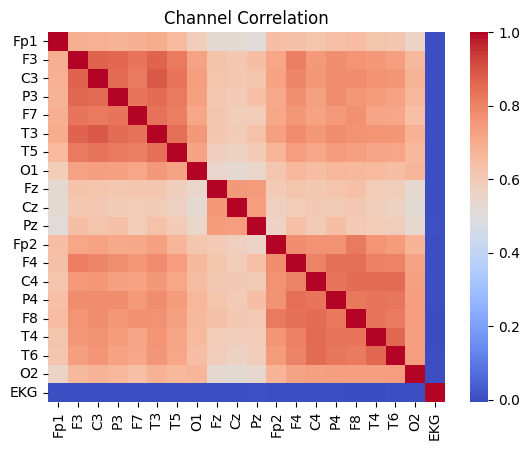

In [26]:
import seaborn as sns

sns.heatmap(df_sample.corr(), cmap='coolwarm')
plt.title('Channel Correlation')

-> EEG 채널들이 서로 비슷. why? 뇌는 동시에 활동하기에 독립적인 채널이 없음. 또 각각의 채널들이 서로 근접해 있음.

but EKG(심장 신호)는 EEG와 낮은 상관관계가 있음을 볼 수 있음